In [1]:
import requests
import pandas as pd
import json

url = "https://archive-api.open-meteo.com/v1/archive"

def request(params):
    req = requests.get(url, params=params)
    data = req.json()
    data_j = json.dumps(data,indent=2, ensure_ascii=False)
    return data
    return data_j

params_spb = {'latitude':59.93863, 
          'longitude':30.31413,
         'daily':["temperature_2m_max",
                  "temperature_2m_min"],
          'start_date':"2025-08-01",
          'end_date':"2025-09-01"
}

params_madrid = {'latitude':40.4165, 
          'longitude':-3.70256,
         'daily':["temperature_2m_max",
                  "temperature_2m_min"],
          'start_date':"2025-08-01",
          'end_date':"2025-09-01"
}

params_washington = {'latitude':38.89511, 
          'longitude':-77.03637,
         'daily':["temperature_2m_max",
                  "temperature_2m_min"],
          'start_date':"2025-08-01",
          'end_date':"2025-09-01"
}

data_spb_raw = request(params_spb)
data_spb = pd.DataFrame({
    'City':'Moscow',
    'Date':data_spb_raw['daily']['time'],
    'Temp_max':data_spb_raw['daily']['temperature_2m_max'],
    'Temp_min':data_spb_raw['daily']['temperature_2m_min']
})

data_madrid_raw = request(params_madrid)
data_madrid = pd.DataFrame({
    'City':'Madrid',
    'Date':data_madrid_raw['daily']['time'],
    'Temp_max':data_madrid_raw['daily']['temperature_2m_max'],
    'Temp_min':data_madrid_raw['daily']['temperature_2m_min']
})

data_washington_raw = request(params_washington)
data_washington = pd.DataFrame({
    'City':'Washington',
    'Date':data_washington_raw['daily']['time'],
    'Temp_max':data_washington_raw['daily']['temperature_2m_max'],
    'Temp_min':data_washington_raw['daily']['temperature_2m_min']
})

data_united = pd.concat([data_spb, data_madrid, data_washington])

print(data_united)

          City        Date  Temp_max  Temp_min
0       Moscow  2025-08-01      27.4      18.0
1       Moscow  2025-08-02      22.2      17.2
2       Moscow  2025-08-03      25.9      15.1
3       Moscow  2025-08-04      27.5      16.7
4       Moscow  2025-08-05      25.6      16.9
..         ...         ...       ...       ...
27  Washington  2025-08-28      25.9      14.8
28  Washington  2025-08-29      25.8      16.8
29  Washington  2025-08-30      24.5      13.6
30  Washington  2025-08-31      26.3      14.4
31  Washington  2025-09-01      25.9      15.3

[96 rows x 4 columns]


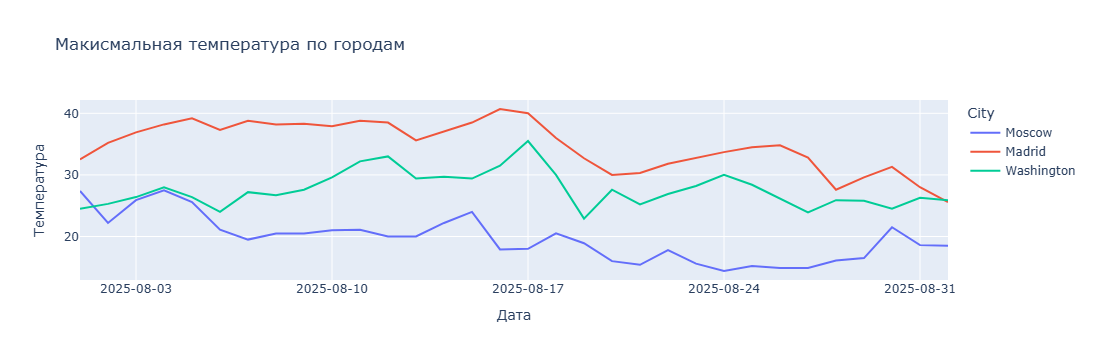

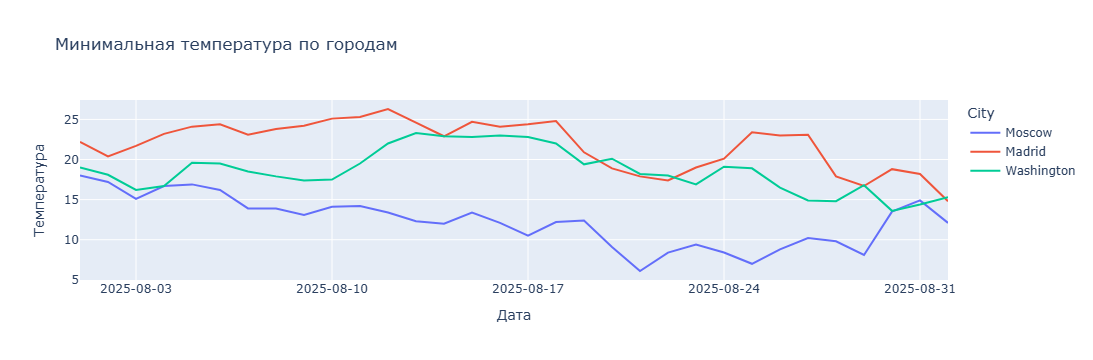

In [2]:
import plotly.express as px
import matplotlib.pyplot as plt

fig_max = px.line(data_united, x='Date', y='Temp_max', color='City',
                  title='Макисмальная температура по городам',
                  labels={'Date':'Дата', 'Temp_max':'Температура'})

fig_min = px.line(data_united, x='Date', y='Temp_min', color='City',
                  title='Минимальная температура по городам',
                  labels={'Date':'Дата', 'Temp_min':'Температура'})

fig_max.update_xaxes(tickformat='%Y-%m-%d')
fig_min.update_xaxes(tickformat='%Y-%m-%d')

fig_max.show()
fig_min.show()